# ============================================================
# SECTION 1: IMPORT LIBRARIES & LOAD DATA
# ============================================================

In [1]:
import pandas as pd

customer = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_name_translation = pd.read_csv('product_category_name_translation.csv')

print(orders['order_status'].value_counts())
print()
print(orders.isnull().sum())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


# ============================================================
# SECTION 2: TARGET VARIABLE CONSTRUCTION
# ============================================================

In [2]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

orders_delivered['order_delivered_customer_date'] = pd.to_datetime(orders_delivered['order_delivered_customer_date'])
orders_delivered['order_estimated_delivery_date'] = pd.to_datetime(orders_delivered['order_estimated_delivery_date'])
orders_delivered['is_late'] = (orders_delivered['order_delivered_customer_date'] > orders_delivered['order_estimated_delivery_date']).astype(int)

# ============================================================
# SECTION 3: JOIN PIPELINE
# ============================================================

In [3]:
order_items_agg = order_items.groupby('order_id').agg(
    num_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()


In [4]:
order_payments_agg = order_payments.groupby('order_id').agg(
    payment_installments=('payment_installments', 'max'),
    total_payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', lambda x: x.mode()[0])
).reset_index()

In [5]:
df = orders_delivered.merge(customer, on='customer_id', how='inner')
print(f"Shape after customers join: {df.shape}")

df = df.merge(order_items_agg, on='order_id', how='left')
print(f"Shape after order_items join: {df.shape}")

df = df.merge(order_payments_agg, on='order_id', how='left')
print(f"Shape after payments join: {df.shape}")

Shape after customers join: (96478, 13)
Shape after order_items join: (96478, 16)
Shape after payments join: (96478, 19)


In [6]:
reviews_clean = order_reviews.sort_values('review_creation_date', ascending=False) \
                              .drop_duplicates(subset='order_id', keep='first') \
                              [['order_id', 'review_score']]

df = df.merge(reviews_clean, on='order_id', how='left')
print(f"Shape after reviews join: {df.shape}")

Shape after reviews join: (96478, 20)


In [7]:
order_product = order_items.groupby('order_id')['product_id'].agg(lambda x: x.mode()[0]).reset_index()
df = df.merge(order_product, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
print(f"Shape after products join: {df.shape}")

Shape after products join: (96478, 29)


In [8]:
order_seller = order_items.groupby('order_id')['seller_id'].agg(lambda x: x.mode()[0]).reset_index()
df = df.merge(order_seller, on='order_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
print(f"Shape after sellers join: {df.shape}")

Shape after sellers join: (96478, 33)


In [9]:
df = df.merge(category_name_translation, on='product_category_name', how='left')
print(f"Shape after category translation join: {df.shape}")

Shape after category translation join: (96478, 34)


In [10]:
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat=('geolocation_lat', 'mean'),
    geolocation_lng=('geolocation_lng', 'mean')
).reset_index()

In [11]:
geo_customer = geo_agg.rename(columns={
    'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
})
df = df.merge(geo_customer, on='customer_zip_code_prefix', how='left')

In [12]:
geo_seller = geo_agg.rename(columns={
    'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
})
df = df.merge(geo_seller, on='seller_zip_code_prefix', how='left')

print(f"Shape after geolocation join: {df.shape}")

Shape after geolocation join: (96478, 38)


# ============================================================
# SECTION 4: DATA CLEANING
# ============================================================

In [13]:
df.isnull().sum()[df.isnull().sum() > 0]

order_approved_at                  14
order_delivered_carrier_date        2
order_delivered_customer_date       8
payment_installments                1
total_payment_value                 1
payment_type                        1
review_score                      646
product_category_name            1361
product_name_lenght              1361
product_description_lenght       1361
product_photos_qty               1361
product_weight_g                   16
product_length_cm                  16
product_height_cm                  16
product_width_cm                   16
product_category_name_english    1381
customer_lat                      264
customer_lng                      264
seller_lat                        216
seller_lng                        216
dtype: int64

In [14]:
cols_to_drop = ['order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'payment_installments',
    'total_payment_value',
    'payment_type']
df = df.dropna(subset=cols_to_drop)
df['review_score'] = df['review_score'].fillna(df['review_score'].median())
df['product_category_name'] = df['product_category_name'].fillna('unknown')
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

In [15]:
for col in ['product_name_lenght', 'product_description_lenght',
            'product_photos_qty', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm']:
    df[col] = df[col].fillna(df[col].median())

In [16]:
geo_state = geolocation.groupby('geolocation_state').agg(
    state_lat=('geolocation_lat', 'mean'),
    state_lng=('geolocation_lng', 'mean')
).reset_index()



In [17]:
df = df.merge(geo_state.rename(columns={'geolocation_state': 'customer_state'}),
              on='customer_state', how='left')

In [18]:
df['customer_lat'] = df['customer_lat'].fillna(df['state_lat'])
df['customer_lng'] = df['customer_lng'].fillna(df['state_lng'])
df = df.drop(columns=['state_lat', 'state_lng'])


In [19]:
df = df.merge(geo_state.rename(columns={'geolocation_state': 'seller_state'}),
              on='seller_state', how='left')

In [20]:
df['seller_lat'] = df['seller_lat'].fillna(df['state_lat'])
df['seller_lng'] = df['seller_lng'].fillna(df['state_lng'])
df = df.drop(columns=['state_lat', 'state_lng'])

In [21]:
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Remaining nulls: 0
Final shape: (96454, 38)


# ============================================================
# SECTION 5: DROP UNUSED COLUMNS
# ============================================================

In [22]:
cols_to_drop = ['order_id', 'customer_id', 'order_status', 'product_category_name']
df = df.drop(columns=cols_to_drop)

print(f"Shape after dropping useless columns: {df.shape}")
print(df.columns.tolist())

Shape after dropping useless columns: (96454, 34)
['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_late', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'num_items', 'total_price', 'total_freight', 'payment_installments', 'total_payment_value', 'payment_type', 'review_score', 'product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']


In [23]:
# 1. Join pipeline (Sections 1-3) must have already run, producing df with raw columns

# 2. Feature engineering - creates approval_time, shipping_time, estimated_delivery_days, order_month
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df['approval_time'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
df['shipping_time'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / 3600
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600 / 24
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.day_of_week
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

print("shipping_time" in df.columns)  # should print True

# 3. NOW the cleaning fix will work
n_negative = (df['shipping_time'] < 0).sum()
print(f"Removing {n_negative} orders with impossible negative shipping_time "
      f"({n_negative / len(df) * 100:.2f}% of dataset)")

df = df[df['shipping_time'] >= 0].copy()
print(f"Shape after removing invalid shipping_time: {df.shape}")
print(f"Late rate after cleaning: {round(df['is_late'].mean() * 100, 2)}%")

True
Removing 1350 orders with impossible negative shipping_time (1.40% of dataset)
Shape after removing invalid shipping_time: (95104, 40)
Late rate after cleaning: 8.19%


In [24]:
df.isnull().sum()

order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
is_late                          0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
num_items                        0
total_price                      0
total_freight                    0
payment_installments             0
total_payment_value              0
payment_type                     0
review_score                     0
product_id                       0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_id                        0
seller_zip_code_prefix           0
seller_city                      0
seller_state        

# ============================================================
# SECTION: EXPLORATORY DATA ANALYSIS
# ============================================================

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('white')
COLOR_ONTIME = '#048A81'
COLOR_LATE = '#C73E1D'
LOW_SAMPLE_THRESHOLD = 100

n_total = len(df)
print(f"Dataset: {n_total} delivered orders")
overall_late_rate = df['is_late'].mean() * 100
print(f"Baseline late rate: {round(overall_late_rate, 2)}%")

Dataset: 95104 delivered orders
Baseline late rate: 8.19%


CAVEAT: low sample states (under 100 orders): ['AC', 'AP', 'RR']


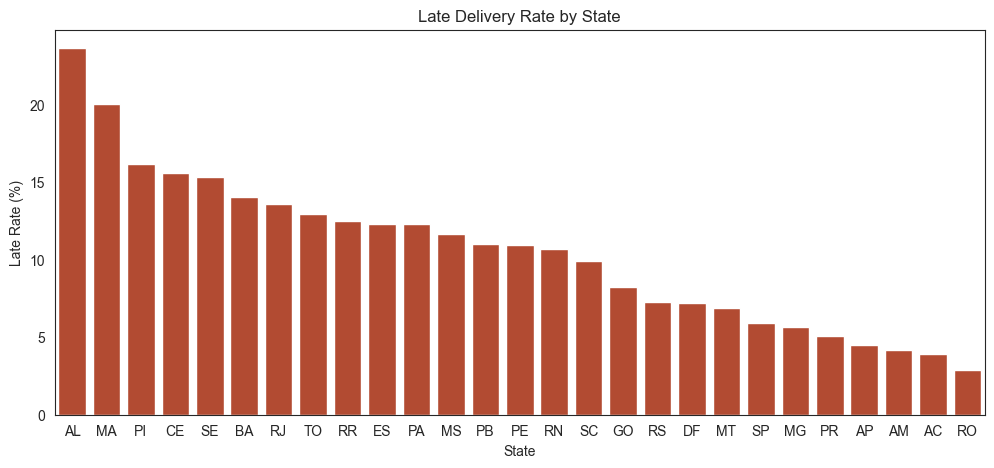

INSIGHT: worst reliable states are ['AL', 'MA', 'PI'].


In [26]:
state_late = df.groupby('customer_state')['is_late'].mean().reset_index()
state_late.columns = ['customer_state', 'late_rate']
state_late['late_rate'] = round(state_late['late_rate'] * 100, 2)
state_late = state_late.sort_values('late_rate', ascending=False)

state_counts = df['customer_state'].value_counts()
low_sample_states = state_counts[state_counts < LOW_SAMPLE_THRESHOLD].index.tolist()
print(f"CAVEAT: low sample states (under {LOW_SAMPLE_THRESHOLD} orders): {low_sample_states}")

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=state_late, x='customer_state', y='late_rate', color=COLOR_LATE, ax=ax)
ax.set_title('Late Delivery Rate by State')
ax.set_xlabel('State')
ax.set_ylabel('Late Rate (%)')
plt.show()

top3 = state_late[~state_late['customer_state'].isin(low_sample_states)].head(3)
print(f"INSIGHT: worst reliable states are {list(top3['customer_state'])}.")

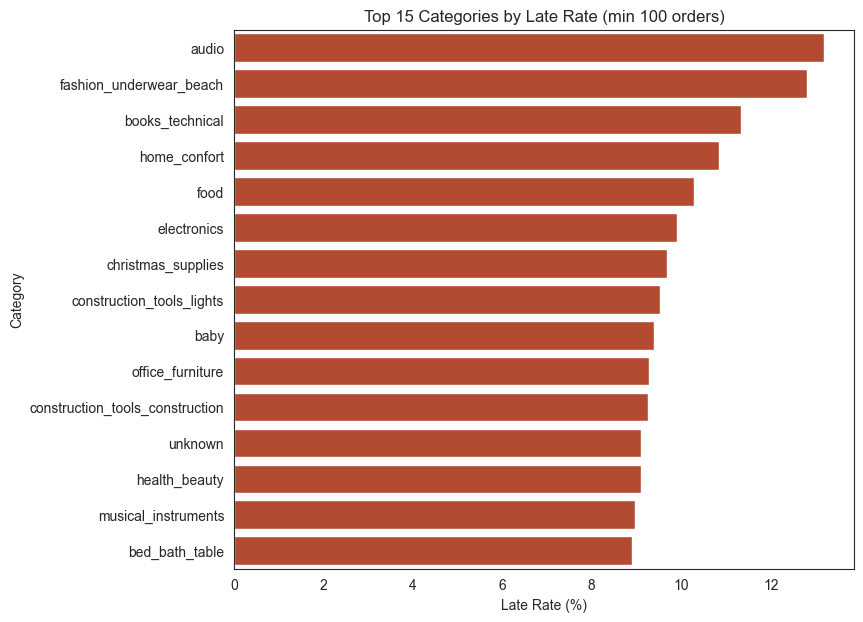

INSIGHT: 'audio' has the highest reliable late rate at 13.2%.


In [27]:
category_late = df.groupby('product_category_name_english')['is_late'].mean().reset_index()
category_late.columns = ['category', 'late_rate']
category_late['late_rate'] = round(category_late['late_rate'] * 100, 2)

category_counts = df['product_category_name_english'].value_counts()
reliable_categories = category_counts[category_counts >= LOW_SAMPLE_THRESHOLD].index
category_late_reliable = category_late[category_late['category'].isin(reliable_categories)]
top15 = category_late_reliable.sort_values('late_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top15, x='late_rate', y='category', color=COLOR_LATE, ax=ax)
ax.set_title('Top 15 Categories by Late Rate (min 100 orders)')
ax.set_xlabel('Late Rate (%)')
ax.set_ylabel('Category')
plt.show()

print(f"INSIGHT: '{top15.iloc[0]['category']}' has the highest reliable late rate at "
      f"{top15.iloc[0]['late_rate']}%.")

Orders with impossible negative shipping time: 0
Orders that sat in the warehouse over 20 days: 619
That's 0.00% and 0.65% of all orders


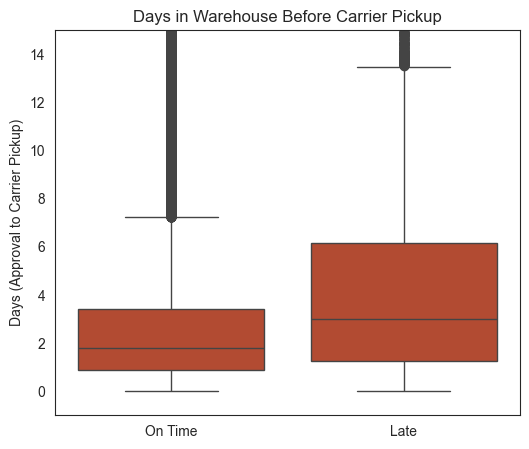

Median days in warehouse - On Time: 1.8 days | Late: 3.0 days


In [28]:
# convert to days - easier to reason about than raw hours
df['shipping_time_days'] = df['shipping_time'] / 24

n_negative = (df['shipping_time_days'] < 0).sum()
n_extreme = (df['shipping_time_days'] > 20).sum()  # over 20 days in warehouse

print(f"Orders with impossible negative shipping time: {n_negative:,}")
print(f"Orders that sat in the warehouse over 20 days: {n_extreme:,}")
print(f"That's {n_negative / len(df) * 100:.2f}% and {n_extreme / len(df) * 100:.2f}% of all orders")

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='is_late', y='shipping_time_days', color=COLOR_LATE, ax=ax)
ax.set_ylim(-1, 15)  # zoom into the range that actually matters
ax.set_xticks([0, 1])
ax.set_xticklabels(['On Time', 'Late'])
ax.set_title('Days in Warehouse Before Carrier Pickup')
ax.set_xlabel('')
ax.set_ylabel('Days (Approval to Carrier Pickup)')
plt.show()

median_ontime = df[df['is_late'] == 0]['shipping_time_days'].median()
median_late = df[df['is_late'] == 1]['shipping_time_days'].median()
print(f"Median days in warehouse - On Time: {median_ontime:.1f} days | Late: {median_late:.1f} days")

In [29]:
print(df.columns.tolist())

['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_late', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'num_items', 'total_price', 'total_freight', 'payment_installments', 'total_payment_value', 'payment_type', 'review_score', 'product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'approval_time', 'shipping_time', 'estimated_delivery_days', 'purchase_month', 'purchase_dayofweek', 'order_month', 'shipping_time_days']


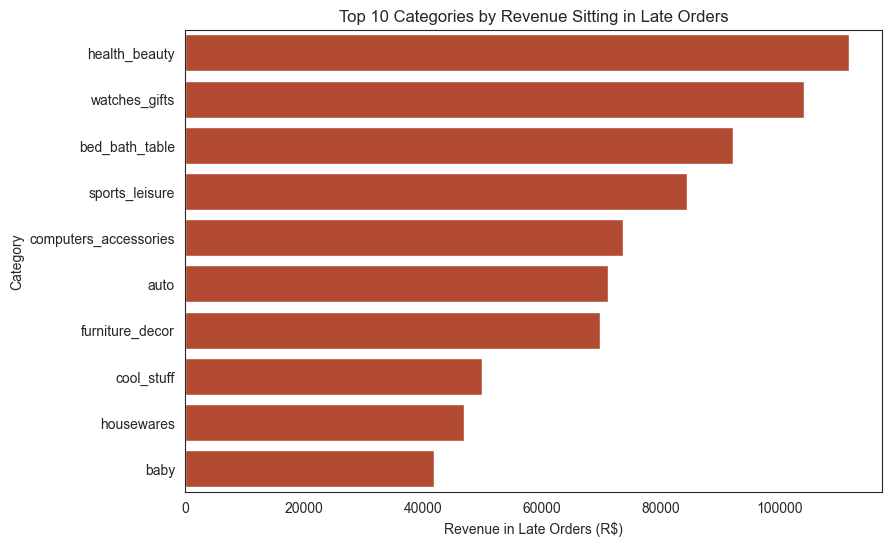

INSIGHT: R$1,154,385 of R$13,046,826 total revenue (8.85%) sits in orders that arrived late. The top category alone, 'health_beauty', accounts for R$111,661. This is the number to weigh against the cost of fixing fulfillment in that category — not just a late-rate percentage.
   product_category_name_english  late_revenue  pct_revenue_at_risk  late_rate
43                 health_beauty     111661.22                 9.21       9.10
71                 watches_gifts     104114.59                 9.05       8.66
7                 bed_bath_table      92144.06                 9.16       8.90
65                sports_leisure      84361.19                 8.94       7.84
15         computers_accessories      73740.49                 8.41       7.83
5                           auto      71220.61                12.43       8.74
39               furniture_decor      69834.60                 9.86       8.62
20                    cool_stuff      49891.42                 8.27       6.85
49          

In [58]:
cat_risk = df.groupby('product_category_name_english').agg(
    total_revenue=('total_price', 'sum'),
    order_count=('is_late', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()

late_only = df[df['is_late'] == 1]
late_revenue_by_cat = late_only.groupby('product_category_name_english')['total_price'].sum().reset_index()
late_revenue_by_cat.columns = ['product_category_name_english', 'late_revenue']

cat_risk = cat_risk.merge(late_revenue_by_cat, on='product_category_name_english', how='left')
cat_risk['late_revenue'] = cat_risk['late_revenue'].fillna(0)
cat_risk['late_rate'] = round(cat_risk['late_rate'] * 100, 2)
cat_risk['pct_revenue_at_risk'] = round(cat_risk['late_revenue'] / cat_risk['total_revenue'] * 100, 2)

cat_risk = cat_risk[cat_risk['order_count'] >= LOW_SAMPLE_THRESHOLD]
top_exposure = cat_risk.sort_values('late_revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_exposure, x='late_revenue', y='product_category_name_english', color=COLOR_LATE, ax=ax)
ax.set_title('Top 10 Categories by Revenue Sitting in Late Orders')
ax.set_xlabel('Revenue in Late Orders (R$)')
ax.set_ylabel('Category')
plt.show()

total_late_revenue = df[df['is_late'] == 1]['total_price'].sum()
total_revenue = df['total_price'].sum()
overall_pct_at_risk = round(total_late_revenue / total_revenue * 100, 2)

print(f"INSIGHT: R${total_late_revenue:,.0f} of R${total_revenue:,.0f} total revenue "
      f"({overall_pct_at_risk}%) sits in orders that arrived late. The top category alone, "
      f"'{top_exposure.iloc[0]['product_category_name_english']}', accounts for "
      f"R${top_exposure.iloc[0]['late_revenue']:,.0f}. This is the number to weigh against "
      f"the cost of fixing fulfillment in that category — not just a late-rate percentage.")
print(top_exposure[['product_category_name_english', 'late_revenue', 'pct_revenue_at_risk', 'late_rate']])

In [46]:

category_delivery_promise = df.groupby('product_category_name_english').agg(
    typical_promised_days=('estimated_delivery_days', 'median'),
    late_rate=('is_late', 'mean'),
    order_count=('is_late', 'count')
).reset_index()

category_delivery_promise['late_rate'] = round(category_delivery_promise['late_rate'] * 100, 2)
category_delivery_promise = category_delivery_promise[category_delivery_promise['order_count'] >= 100]

typical_days_across_categories = category_delivery_promise['typical_promised_days'].median()
typical_late_rate_across_categories = category_delivery_promise['late_rate'].median()

categories_with_real_fulfillment_problem = category_delivery_promise[
    (category_delivery_promise['typical_promised_days'] > typical_days_across_categories) &
    (category_delivery_promise['late_rate'] > typical_late_rate_across_categories)
]
categories_with_real_fulfillment_problem = categories_with_real_fulfillment_problem.sort_values('late_rate', ascending=False)

print(f"{len(categories_with_real_fulfillment_problem)} categories flagged")


13 categories flagged


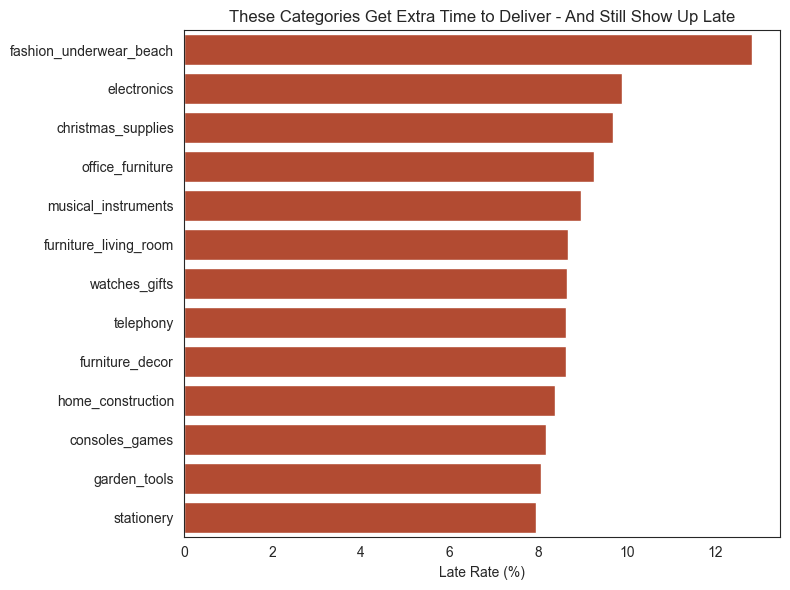

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=categories_with_real_fulfillment_problem.sort_values('late_rate', ascending=False),
            x='late_rate', y='product_category_name_english', color=COLOR_LATE, ax=ax)
ax.set_title('These Categories Get Extra Time to Deliver - And Still Show Up Late')
ax.set_xlabel('Late Rate (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# ============================================================
# EXPORT olist_final.csv -> PostgreSQL
# ============================================================

In [32]:
import os
df.to_csv('olist_final.csv', index=False)
print(f"Saved olist_final.csv with shape {df.shape}")

# confirm it's actually on disk
print("File exists:", os.path.exists('olist_final.csv'))

Saved olist_final.csv with shape (95104, 41)
File exists: True


In [33]:

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")



In [34]:
connection_string = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(connection_string)

df = pd.read_csv('olist_final.csv')
print(f"Loaded olist_final.csv: {df.shape}")

df.to_sql(name='olist_final', con=engine, if_exists='replace', index=False, chunksize=5000)
print(f"Uploaded {df.shape[0]:,} rows to table 'olist_final'")

Loaded olist_final.csv: (95104, 41)
Uploaded 95,104 rows to table 'olist_final'


In [35]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM olist_final"))
    print("Row count in PostgreSQL:", result.scalar())

Row count in PostgreSQL: 95104


In [36]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database();"))
    print("Connected to database:", result.scalar())

    result2 = conn.execute(text("SELECT current_schema();"))
    print("Current schema:", result2.scalar())

    result3 = conn.execute(text("SELECT table_schema, table_name FROM information_schema.tables WHERE table_name = 'olist_final';"))
    print("Table found at:")
    for row in result3:
        print(" -", row)

Connected to database: olist_db
Current schema: public
Table found at:
 - ('public', 'olist_final')
